# 3. Collaborative Filtering — Benchmark Dataset

Se evaluaron cuatro modelos de **filtrado colaborativo** (CF) sobre el dataset de benchmark. A diferencia de Content-Based (que usa similitud semántica entre películas), CF aprende de los **patrones colectivos de calificación**: si dos usuarios calificaron alto las mismas películas, es probable que compartan gustos.

### ¿Cómo aprende CF?

Cada modelo asigna a cada usuario y cada película un **embedding** — un vector numérico que resume sus características latentes. La predicción se calcula como el producto punto entre el embedding del usuario y el de la película: si apuntan en la misma dirección, el score es alto.

### Protocolo de búsqueda

Se realizó un **RandomSearch** de 20 trials por modelo. Cada trial se entrenó sobre `inner_train` (80% del train) y se evaluó con **NDCG@10 full-catalog** sobre 500 usuarios aleatorios de `inner_val`. Se seleccionó el modelo con mejor NDCG@10 de validación, se re-entrenó sobre el train completo, y se evaluó con el protocolo final.

In [1]:
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import json as _json
import ml.config as cfg
from ml.evaluation.splits import movielens_split, survey_split_sampled
from ml.evaluation.notebook_utils import evaluate_movielens, plot_dataset_metrics
from ml.evaluation.metrics import ndcg_at_k
from ml.models.surprise_svd import SurpriseSVD, SurpriseSVDpp
from ml.models.lightgcn import LightGCN
from ml.models.bprmf import BPRMF
from IPython.display import Markdown, display
from tabulate import tabulate as _tabulate
from ml.evaluation.notebook_utils import (
    evaluate_survey, print_metrics, plot_survey_metrics,
    RATINGS_SURVEY_PATH, MOVIES_PATH as ML_MOVIES_PATH,
)

K = 10
RNG = np.random.default_rng(42)
N_ITEMS = cfg.catalog_size()
print(f"N_ITEMS={N_ITEMS}")


N_ITEMS=3830


In [2]:
ml_train_full, ml_test = movielens_split(cfg.RATINGS_PATH)

# Random inner split for validation
inner_train_parts, inner_val_parts = [], []
for _, group in ml_train_full.groupby("user_id", sort=False):
    group = group.sample(frac=1.0, random_state=42)
    cut = max(1, int(len(group) * 0.8))
    inner_train_parts.append(group.iloc[:cut])
    inner_val_parts.append(group.iloc[cut:])

inner_train = pd.concat(inner_train_parts).reset_index(drop=True)
inner_val = pd.concat(inner_val_parts).reset_index(drop=True)
print(f"inner_train={len(inner_train):,}  inner_val={len(inner_val):,}")

# Validation subset: 500 random users with positives
_eligible = inner_val[inner_val["rating"] >= 4.0]["user_id"].unique()
SUBSET_USERS = RNG.choice(_eligible, size=min(500, len(_eligible)), replace=False)
print(f"Validation subset: {len(SUBSET_USERS)} users")

inner_train=635,759  inner_val=162,050
Validation subset: 500 users


## 2. Helpers de RandomSearch

Se definieron funciones auxiliares para evaluar NDCG@10 full-catalog sobre un subconjunto de 500 usuarios de validación (para mantener el costo computacional manejable) y para ejecutar el RandomSearch con 10 trials por modelo.

In [3]:
def evaluate_ndcg_full_subset(model, val_df, k, n_items, subset_users):
    relevant = val_df[val_df["rating"] >= 4.0].groupby("user_id")["movie_idx"].apply(set).to_dict()
    scores = []
    for uid in subset_users:
        rel = relevant.get(int(uid))
        if not rel: continue
        recs = model.recommend(int(uid), n=k)
        if not recs: continue
        scores.append(ndcg_at_k(recs, rel, k))
    return float(np.mean(scores)) if scores else 0.0


def random_search(model_cls, space, n_trials, train_df, val_df, k, n_items, subset_users, label):
    rows = []
    for trial in range(n_trials):
        params = {key: RNG.choice(vals) for key, vals in space.items()}
        params = {k: (int(v) if isinstance(v, (np.integer,)) else float(v)) for k, v in params.items()}
        t0 = time.time()
        model = model_cls(**params)
        model.fit(train_df)
        row = {"elapsed_s": round(time.time() - t0, 1)}
        row["ndcg@10"] = evaluate_ndcg_full_subset(model, val_df, k, n_items, subset_users)
        row.update(params)
        rows.append(row)
        print(f"[{label}] trial {trial+1}/{n_trials}  ndcg={row["ndcg@10"]:.4f}  {row["elapsed_s"]}s  {params}")
    df = pd.DataFrame(rows).sort_values("ndcg@10", ascending=False).reset_index(drop=True)
    df.insert(0, "model", label)
    return df

print("Helpers ready")

Helpers ready


## 3. SVD (FunkSVD)

**Tipo:** Factorización de matrices (ML clásico).

**¿Qué hace?** Predice el rating que un usuario le daría a una película.

**¿Cómo?** Aprende un embedding (vector latente) por usuario (`pu`) y uno por película (`qi`), ambos de dimensión `d`. El score se calcula como:

```
score(u, i) = μ + bu + bi + pu · qi
```

- `μ` = media global de ratings
- `bu`, `bi` = biases (tendencias generales del usuario y la película)
- `pu · qi` = producto punto que captura la afinidad latente

**Entrenamiento:** SGD minimizando MSE entre rating real y predicho, con regularización L2. Los embeddings se inicializan aleatoriamente y se ajustan iterativamente. Usa ratings explícitos (0.5–5.0).

In [ ]:
svd_space = {
    "n_factors": [50, 100, 150, 200],
    "n_epochs": [20, 30, 40, 50],
    "lr_all": [0.002, 0.005, 0.01],
    "reg_all": [0.001, 0.01, 0.05, 0.1],
}

svd_results = random_search(
    SurpriseSVD, svd_space, n_trials=20,
    train_df=inner_train, val_df=inner_val,
    k=K, n_items=N_ITEMS, subset_users=SUBSET_USERS,
    label="SVD",
)
display(svd_results.head())

## 4. SVD++

**Tipo:** Factorización de matrices con feedback implícito (ML clásico).

**¿Qué hace?** Lo mismo que SVD, pero enriquece el embedding del usuario con señal implícita — qué películas calificó, sin importar el valor.

**¿Cómo?** Al embedding explícito `pu` le suma el promedio normalizado de embeddings implícitos (`yj`) de las películas vistas:

```
score(u, i) = μ + bu + bi + (pu + 1/√|N(u)| · Σ yj) · qi
```

- `N(u)` = películas que el usuario calificó (cualquier valor)
- `yj` = embedding implícito de cada película en `N(u)`
- `1/√|N(u)|` = normalización por cantidad de películas vistas

**Intuición:** Un usuario que vio 200 películas de acción tiene un vector distinto al que vio 10, aunque sus ratings explícitos sean iguales.

**Entrenamiento:** SGD minimizando MSE + regularización L2. Es 5–10× más lento que SVD por el cálculo del término implícito en cada paso.

In [ ]:
svdpp_space = {
    "n_factors": [50, 100, 150],
    "n_epochs": [20, 30, 40],
    "lr_all": [0.002, 0.005, 0.01],
    "reg_all": [0.001, 0.01, 0.05],
}

svdpp_results = random_search(
    SurpriseSVDpp, svdpp_space, n_trials=20,
    train_df=inner_train, val_df=inner_val,
    k=K, n_items=N_ITEMS, subset_users=SUBSET_USERS,
    label="SVD++",
)
display(svdpp_results.head())

[SVD++] trial 1/20  ndcg=0.0282  268.2s  {'n_factors': 150, 'n_epochs': 40, 'lr_all': 0.01, 'reg_all': 0.05}
[SVD++] trial 2/20  ndcg=0.0278  92.2s  {'n_factors': 100, 'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.05}
[SVD++] trial 3/20  ndcg=0.0726  201.4s  {'n_factors': 150, 'n_epochs': 30, 'lr_all': 0.002, 'reg_all': 0.01}
[SVD++] trial 4/20  ndcg=0.0766  184.3s  {'n_factors': 100, 'n_epochs': 40, 'lr_all': 0.005, 'reg_all': 0.001}
[SVD++] trial 5/20  ndcg=0.0394  101.5s  {'n_factors': 50, 'n_epochs': 40, 'lr_all': 0.01, 'reg_all': 0.001}
[SVD++] trial 6/20  ndcg=0.0257  138.5s  {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.05}
[SVD++] trial 7/20  ndcg=0.0997  50.7s  {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.002, 'reg_all': 0.001}
[SVD++] trial 8/20  ndcg=0.0744  267.8s  {'n_factors': 150, 'n_epochs': 40, 'lr_all': 0.002, 'reg_all': 0.01}
[SVD++] trial 9/20  ndcg=0.0997  50.7s  {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.002, 'reg_all': 0.001}
[SVD++] trial 1

,model,elapsed_s,ndcg@10,n_factors,n_epochs,lr_all,reg_all
0,SVD++,50.7,0.099659,50,20,0.002,0.001
1,SVD++,50.7,0.099659,50,20,0.002,0.001
2,SVD++,97.4,0.099270,100,20,0.002,0.001
3,SVD++,184.3,0.076624,100,40,0.005,0.001
4,SVD++,267.8,0.074449,150,40,0.002,0.010


## 5. LightGCN

**Tipo:** Graph Neural Network simplificada (sin pesos entrenables por capa ni no-linealidades).

**¿Qué hace?** Propaga embeddings a través de un **grafo bipartito** usuario↔película para capturar similitud indirecta entre usuarios.

**¿Cómo?** Construye un grafo donde cada arista = "usuario calificó película". Propaga por L capas:

```
e_u^(l+1) = Σ  1/√(deg_u · deg_i) · e_i^(l)    (para cada película i que u vio)
e_i^(l+1) = Σ  1/√(deg_u · deg_i) · e_u^(l)    (para cada usuario u que vio i)
```

Embedding final = promedio de todas las capas (0 a L). El score incluye biases ajustados post-entrenamiento:

```
score(u, i) = μ + bu + bi + Eu_final[u] · Ei_final[i]
```

Con L=3 capas, un usuario recibe señal de otros usuarios a 3 saltos de distancia en el grafo.

**Entrenamiento:** BPR loss (ranking pairwise) con SGD sobre mini-batches. Para cada interacción positiva, samplea un negativo y empuja al positivo a tener mayor score. Incluye **early stopping** sobre la BPR loss para evitar sobreajuste.

In [ ]:
lightgcn_space = {
    "n_factors": [32, 64, 128],
    "n_epochs": [50, 100],
    "lr": [0.005, 0.01, 0.02],
    "n_layers": [2, 3, 4],
    "reg": [0.0001, 0.001],
    "patience": [10, 20],
}

lightgcn_results = random_search(
    LightGCN, lightgcn_space, n_trials=20,
    train_df=inner_train, val_df=inner_val,
    k=K, n_items=N_ITEMS, subset_users=SUBSET_USERS,
    label="LightGCN",
)
display(lightgcn_results.head())

[LightGCN] trial 1/20  ndcg=0.1219  274.0s  {'n_factors': 64, 'n_epochs': 100, 'lr': 0.01, 'n_layers': 4, 'reg': 0.0001, 'patience': 20}
[LightGCN] trial 2/20  ndcg=0.0797  80.7s  {'n_factors': 32, 'n_epochs': 50, 'lr': 0.01, 'n_layers': 4, 'reg': 0.001, 'patience': 20}
[LightGCN] trial 3/20  ndcg=0.0735  98.0s  {'n_factors': 64, 'n_epochs': 50, 'lr': 0.005, 'n_layers': 2, 'reg': 0.0001, 'patience': 10}
[LightGCN] trial 4/20  ndcg=0.0561  68.4s  {'n_factors': 32, 'n_epochs': 50, 'lr': 0.005, 'n_layers': 3, 'reg': 0.001, 'patience': 20}
[LightGCN] trial 5/20  ndcg=0.0735  127.5s  {'n_factors': 64, 'n_epochs': 50, 'lr': 0.005, 'n_layers': 2, 'reg': 0.0001, 'patience': 20}
[LightGCN] trial 6/20  ndcg=0.0721  58.8s  {'n_factors': 32, 'n_epochs': 50, 'lr': 0.005, 'n_layers': 2, 'reg': 0.001, 'patience': 20}
[LightGCN] trial 7/20  ndcg=0.1651  274.9s  {'n_factors': 64, 'n_epochs': 100, 'lr': 0.02, 'n_layers': 4, 'reg': 0.0001, 'patience': 20}
[LightGCN] trial 8/20  ndcg=0.1746  234.4s  {'n_f

,model,elapsed_s,ndcg@10,n_factors,n_epochs,lr,n_layers,reg,patience
0,LightGCN,427.1,0.183744,128,100,0.02,3,0.00010,10
1,LightGCN,419.0,0.175966,128,100,0.02,3,0.00100,10
2,LightGCN,234.4,0.174649,64,100,0.02,3,0.00100,20
3,LightGCN,175.1,0.170831,128,50,0.02,2,0.00001,10
4,LightGCN,631.4,0.170831,128,50,0.02,2,0.00001,20


## 6. BPR-MF

**Tipo:** Factorización de matrices con pérdida de ranking (ML clásico).

**¿Qué hace?** Aprende embeddings de usuario e ítem optimizando directamente el orden del ranking.

**¿Cómo?** Binariza los ratings (≥ 4.0 → positivo) y construye una matriz esparsa usuario×ítem. El score es solo el producto punto:

```
score(u, i) = user_factors[u] · item_factors[i]
```

Sin biases ni media global — toda la señal está en los embeddings.

**Entrenamiento:** BPR loss — para cada tripleta (usuario, positivo, negativo), maximiza `σ(score_pos - score_neg)`. Usa la librería `implicit` (Cython multi-threaded).

**vs LightGCN:** Misma loss (BPR), pero sin propagación por grafo. Cada embedding es independiente.

**vs SVD:** Misma estructura (embeddings + producto punto), pero SVD optimiza predicción de rating (MSE) y BPR-MF optimiza ranking (BPR).

In [ ]:
bprmf_space = {
    "n_factors": [32, 64, 128, 256],
    "n_epochs": [50, 100, 200],
    "lr": [0.005, 0.01, 0.02],
    "reg": [0.001, 0.01, 0.1],
}

bprmf_results = random_search(
    BPRMF, bprmf_space, n_trials=20,
    train_df=inner_train, val_df=inner_val,
    k=K, n_items=N_ITEMS, subset_users=SUBSET_USERS,
    label="BPR-MF",
)
display(bprmf_results.head())

[BPR-MF] trial 1/20  ndcg=0.0915  18.8s  {'n_factors': 256, 'n_epochs': 200, 'lr': 0.02, 'reg': 0.01}
[BPR-MF] trial 2/20  ndcg=0.1374  9.1s  {'n_factors': 256, 'n_epochs': 100, 'lr': 0.005, 'reg': 0.1}
[BPR-MF] trial 3/20  ndcg=0.1388  1.5s  {'n_factors': 32, 'n_epochs': 50, 'lr': 0.02, 'reg': 0.001}
[BPR-MF] trial 4/20  ndcg=0.1374  9.0s  {'n_factors': 256, 'n_epochs': 100, 'lr': 0.005, 'reg': 0.1}
[BPR-MF] trial 5/20  ndcg=0.1043  6.3s  {'n_factors': 128, 'n_epochs': 100, 'lr': 0.02, 'reg': 0.05}
[BPR-MF] trial 6/20  ndcg=0.1127  8.2s  {'n_factors': 32, 'n_epochs': 300, 'lr': 0.01, 'reg': 0.05}
[BPR-MF] trial 7/20  ndcg=0.0915  17.3s  {'n_factors': 256, 'n_epochs': 200, 'lr': 0.02, 'reg': 0.01}
[BPR-MF] trial 8/20  ndcg=0.0901  2.8s  {'n_factors': 32, 'n_epochs': 100, 'lr': 0.05, 'reg': 0.05}
[BPR-MF] trial 9/20  ndcg=0.0579  9.4s  {'n_factors': 64, 'n_epochs': 300, 'lr': 0.05, 'reg': 0.1}
[BPR-MF] trial 10/20  ndcg=0.1008  6.3s  {'n_factors': 64, 'n_epochs': 200, 'lr': 0.02, 'reg':

,model,elapsed_s,ndcg@10,n_factors,n_epochs,lr,reg
0,BPR-MF,3.2,0.172290,64,100,0.005,0.001
1,BPR-MF,1.5,0.138759,32,50,0.020,0.001
2,BPR-MF,9.1,0.137399,256,100,0.005,0.100
3,BPR-MF,9.0,0.137399,256,100,0.005,0.100
4,BPR-MF,6.3,0.127382,64,200,0.005,0.001


## 7. Selección del modelo ganador y re-entrenamiento

Se compararon los mejores trials de cada modelo por NDCG@10 de validación. El ganador se re-entrenó sobre el **train completo** (`ml_train_full`) para aprovechar el 100% de los datos de entrenamiento disponibles.

In [8]:
model_results = {
    "SVD": svd_results,
    "SVD++": svdpp_results,
    "LightGCN": lightgcn_results,
    "BPR-MF": bprmf_results,
}

winners = pd.DataFrame([
    df.iloc[0] for df in model_results.values()
]).reset_index(drop=True)
print("Best per model:")
print(winners[["model", "ndcg@10", "elapsed_s"]].to_string(index=False))

best_idx = int(winners["ndcg@10"].idxmax())
best_row = winners.iloc[best_idx]
best_model_name = best_row["model"]
print(f"\nWinner: {best_model_name}  (ndcg@10={best_row["ndcg@10"]:.4f})")

if best_model_name == "SVD":
    best_cls, hp_keys = SurpriseSVD, ["n_factors", "n_epochs", "lr_all", "reg_all"]
elif best_model_name == "SVD++":
    best_cls, hp_keys = SurpriseSVDpp, ["n_factors", "n_epochs", "lr_all", "reg_all"]
elif best_model_name == "BPR-MF":
    best_cls, hp_keys = BPRMF, ["n_factors", "n_epochs", "lr", "reg"]
else:
    best_cls, hp_keys = LightGCN, ["n_factors", "n_epochs", "lr", "n_layers", "patience"]

best_params = {k: best_row[k] for k in hp_keys if k in best_row and pd.notna(best_row[k])}
best_params = {k: (int(v) if isinstance(v, (np.integer, int)) or (isinstance(v, float) and v.is_integer()) else float(v)) for k, v in best_params.items()}
print("hyperparameters:", best_params)

best_model = best_cls(**best_params)
best_model.fit(ml_train_full)
print("Retrained on full train")

Best per model:
   model  ndcg@10  elapsed_s
     SVD 0.076739        3.6
   SVD++ 0.099659       50.7
LightGCN 0.183744      427.1
  BPR-MF 0.172290        3.2

Winner: LightGCN  (ndcg@10=0.1837)
hyperparameters: {'n_factors': 128, 'n_epochs': 100, 'lr': 0.02, 'n_layers': 3, 'patience': 10}
Retrained on full train


## 8. Evaluación final — Benchmark

Se evaluó el modelo ganador con el protocolo **full-catalog** sobre el test set de benchmark, midiendo las 6 métricas definidas en el glosario del notebook 1. Estos números son directamente comparables con los de Popularity y Content-Based.


LightGCN — Evaluación final (K=10):
╒════════════════════╤═══════════╕
│ Métrica            │     Valor │
╞════════════════════╪═══════════╡
│ Precision@K        │    0.2664 │
├────────────────────┼───────────┤
│ Recall@K (norm)    │    0.2808 │
├────────────────────┼───────────┤
│ NDCG@K             │    0.3079 │
├────────────────────┼───────────┤
│ Diversity@K        │    0.4072 │
├────────────────────┼───────────┤
│ Novelty@K          │    0.5182 │
├────────────────────┼───────────┤
│ Coverage           │    0.4807 │
├────────────────────┼───────────┤
│ Usuarios evaluados │ 5987      │
├────────────────────┼───────────┤
│ Usuarios omitidos  │    0      │
╘════════════════════╧═══════════╛


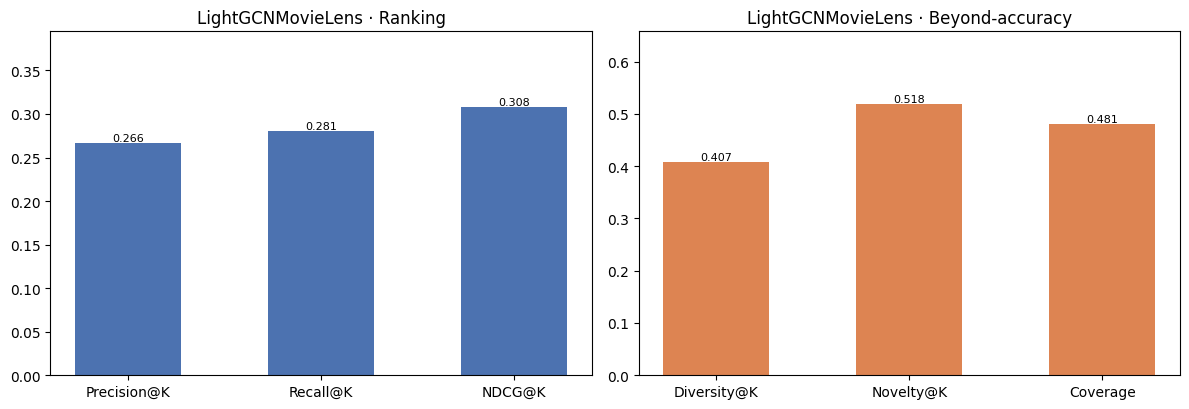

In [9]:
cosine_sim = cfg.load_cosine_sim()
popularity = cfg.load_popularity()

# evaluate_movielens llama model.fit internamente, pero ya se entrenó.
# Se usa un wrapper que omite el re-entrenamiento.
class _NoFitWrapper:
    def __init__(self, model):
        self._model = model
    def fit(self, *a, **kw): pass
    def recommend(self, *a, **kw): return self._model.recommend(*a, **kw)
    def score_all(self, *a, **kw): return self._model.score_all(*a, **kw)

results = evaluate_movielens(
    _NoFitWrapper(best_model), ml_train_full, ml_test, K, cosine_sim, popularity, N_ITEMS
)

# Tabla de métricas
metric_keys = ['precision', 'recall', 'ndcg', 'diversity', 'novelty', 'coverage']
metric_names = ['Precision@K', 'Recall@K (norm)', 'NDCG@K', 'Diversity@K', 'Novelty@K', 'Coverage']
rows = [[name, f"{results[key]:.4f}"] for key, name in zip(metric_keys, metric_names)]
rows.append(['Usuarios evaluados', f"{results['n_evaluated']:,}"])
rows.append(['Usuarios omitidos', f"{results['n_skipped']:,}"])
print(f"\n{best_model_name} — Evaluación final (K={K}):")
print(_tabulate(rows, headers=['Métrica', 'Valor'], tablefmt='fancy_grid'))

plot_dataset_metrics(movielens=results, title_prefix=best_model_name)


## 9. Evaluación sobre el dataset de Survey (sampled LOO)

Se evaluó el modelo ganador sobre los ~125 usuarios reales del Survey con el protocolo **leave-one-out sampled** (1 positivo + 99 negativos). Métricas: **HR@K** y **NDCG@K**.

Para CF, el train de cada fold de Survey se combinó con los ratings de MovieLens para que el modelo tenga acceso a embeddings ricos aprendidos de los ~6,000 usuarios del benchmark. Sin esta combinación, los ~125 usuarios de Survey no proporcionan suficiente señal colaborativa.

Survey folds: 118


### LightGCN — Métricas Survey — K=10

╒═════════════╤═════════╕
│ Métrica     │   Valor │
╞═════════════╪═════════╡
│ hr          │   1     │
├─────────────┼─────────┤
│ ndcg        │   0.795 │
├─────────────┼─────────┤
│ n_evaluated │ 118     │
├─────────────┼─────────┤
│ n_skipped   │   0     │
╘═════════════╧═════════╛


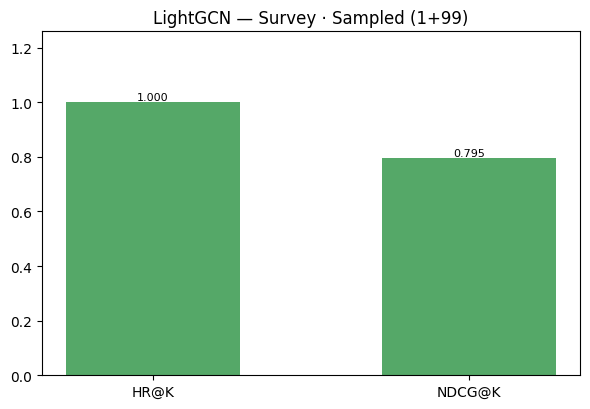

In [10]:
sv_folds = survey_split_sampled(
    RATINGS_SURVEY_PATH, cfg.MOVIES_PATH, n_negatives=99, seed=42,
)
print(f"Survey folds: {len(sv_folds)}")

# Factory creates fresh instances with the winning hyperparameters
_cf_params = best_params.copy()
_cf_cls = best_cls

survey_results = evaluate_survey(
    model_factory=lambda: _cf_cls(**_cf_params),
    folds=sv_folds,
    k=K,
    n_items=N_ITEMS,
)
display(Markdown(f'### {best_model_name} — Métricas Survey — K={K}'))
print_metrics(survey_results)
plot_survey_metrics(survey_results, title_prefix=f'{best_model_name} — ')

## Ejemplos de recomendaciones

Se mostraron las top-5 películas favoritas y las top-10 recomendaciones del modelo CF ganador para los mismos 3 usuarios aleatorios (seed=42) que en los notebooks 1 y 2, para permitir una comparación directa entre Popularity, Content-Based y Collaborative Filtering.

In [12]:
movies_df = pd.read_csv(cfg.MOVIES_PATH)
lookup = {int(r.movie_id): (r.title, str(r.release_date)[:4] if pd.notna(getattr(r, 'release_date', None)) else '—')
          for r in movies_df.itertuples(index=False)}

# Mismos usuarios que en notebooks 1 y 2 (seed=42)
rng_ex = np.random.default_rng(42)
sample_users = rng_ex.choice(ml_test['user_id'].unique(), size=3, replace=False).tolist()

for uid in sample_users:
    display(Markdown(f'### Usuario {uid}'))

    # Top-5 películas favoritas del usuario en train
    user_train = ml_train_full[ml_train_full['user_id'] == uid].sort_values('rating', ascending=False).head(5)
    fav_rows = []
    for rank, row in enumerate(user_train.itertuples(index=False), 1):
        title, year = lookup.get(int(row.movie_idx), (f'<idx {row.movie_idx}>', '—'))
        fav_rows.append([rank, title, year, f'{row.rating:.1f}'])
    display(Markdown('**Top-5 películas favoritas (en train):**'))
    print(_tabulate(fav_rows, headers=['#', 'Título', 'Año', 'Rating'], tablefmt='fancy_grid'))

    # Top-10 recomendaciones del modelo CF ganador
    recs = best_model.recommend(int(uid), n=K)
    rec_rows = []
    for rank, mid in enumerate(recs, 1):
        title, year = lookup.get(int(mid), (f'<idx {mid}>', '—'))
        rec_rows.append([rank, title, year])
    display(Markdown(f'**Top-{K} recomendaciones ({best_model_name}):**'))
    print(_tabulate(rec_rows, headers=['#', 'Título', 'Año'], tablefmt='fancy_grid'))
    print()


### Usuario 3927

**Top-5 películas favoritas (en train):**

╒═════╤═══════════════════════════════════════╤═══════╤══════════╕
│   # │ Título                                │   Año │   Rating │
╞═════╪═══════════════════════════════════════╪═══════╪══════════╡
│   1 │ The Way Way Back                      │  2013 │        5 │
├─────┼───────────────────────────────────────┼───────┼──────────┤
│   2 │ Bridesmaids                           │  2011 │        5 │
├─────┼───────────────────────────────────────┼───────┼──────────┤
│   3 │ Ocean's Thirteen                      │  2007 │        5 │
├─────┼───────────────────────────────────────┼───────┼──────────┤
│   4 │ Anchorman: The Legend of Ron Burgundy │  2004 │        5 │
├─────┼───────────────────────────────────────┼───────┼──────────┤
│   5 │ National Treasure: Book of Secrets    │  2007 │        5 │
╘═════╧═══════════════════════════════════════╧═══════╧══════════╛


**Top-10 recomendaciones (LightGCN):**

╒═════╤═════════════════════╤═══════╕
│   # │ Título              │   Año │
╞═════╪═════════════════════╪═══════╡
│   1 │ Easy A              │  2010 │
├─────┼─────────────────────┼───────┤
│   2 │ Hitch               │  2005 │
├─────┼─────────────────────┼───────┤
│   3 │ The Bucket List     │  2007 │
├─────┼─────────────────────┼───────┤
│   4 │ Step Brothers       │  2008 │
├─────┼─────────────────────┼───────┤
│   5 │ Mean Girls          │  2004 │
├─────┼─────────────────────┼───────┤
│   6 │ Yes Man             │  2008 │
├─────┼─────────────────────┼───────┤
│   7 │ I Love You, Man     │  2009 │
├─────┼─────────────────────┼───────┤
│   8 │ Role Models         │  2008 │
├─────┼─────────────────────┼───────┤
│   9 │ Night at the Museum │  2006 │
├─────┼─────────────────────┼───────┤
│  10 │ The Other Guys      │  2010 │
╘═════╧═════════════════════╧═══════╛



...

### Usuario 4641

**Top-5 películas favoritas (en train):**

╒═════╤════════════════════════════════╤═══════╤══════════╕
│   # │ Título                         │   Año │   Rating │
╞═════╪════════════════════════════════╪═══════╪══════════╡
│   1 │ The Matrix                     │  1999 │        5 │
├─────┼────────────────────────────────┼───────┼──────────┤
│   2 │ The Dawn Wall                  │  2017 │        5 │
├─────┼────────────────────────────────┼───────┼──────────┤
│   3 │ Parasite                       │  2019 │        5 │
├─────┼────────────────────────────────┼───────┼──────────┤
│   4 │ La Maison en Petits Cubes      │  2008 │        5 │
├─────┼────────────────────────────────┼───────┼──────────┤
│   5 │ Guardians of the Galaxy Vol. 2 │  2017 │        5 │
╘═════╧════════════════════════════════╧═══════╧══════════╛


**Top-10 recomendaciones (LightGCN):**

╒═════╤══════════════════════════════════════╤═══════╕
│   # │ Título                               │   Año │
╞═════╪══════════════════════════════════════╪═══════╡
│   1 │ Star Trek: First Contact             │  1996 │
├─────┼──────────────────────────────────────┼───────┤
│   2 │ Robot Chicken: Star Wars Episode II  │  2008 │
├─────┼──────────────────────────────────────┼───────┤
│   3 │ Ghost in the Shell                   │  1995 │
├─────┼──────────────────────────────────────┼───────┤
│   4 │ Avengers: Infinity War               │  2018 │
├─────┼──────────────────────────────────────┼───────┤
│   5 │ The Iron Giant                       │  1999 │
├─────┼──────────────────────────────────────┼───────┤
│   6 │ Robot Chicken: Star Wars Episode III │  2010 │
├─────┼──────────────────────────────────────┼───────┤
│   7 │ Black Hawk Down                      │  2001 │
├─────┼──────────────────────────────────────┼───────┤
│   8 │ John Wick: Chapter 3 - Parabellum    │  2019 │
├─────┼───

## 10. Persistencia del modelo ganador

Se guardó el modelo ganador a disco junto con un archivo JSON de metadatos que contiene el nombre del modelo, los hiperparámetros elegidos y la métrica de validación. Esto permite reconstruir el modelo en notebooks posteriores sin re-entrenar.

In [ ]:
# SAVED_DIR = Path('..') / 'models' / 'saved'
# SAVED_DIR.mkdir(parents=True, exist_ok=True)

# Save model artifact
if best_model_name == 'LightGCN':
#     best_model.save(SAVED_DIR / 'collaborative.npz')
else:
    import pickle
#     with open(SAVED_DIR / 'collaborative.pkl', 'wb') as f:
#         pickle.dump(best_model, f)

# Save metadata
meta = {
    'model': best_model_name,
    'hyperparameters': best_params,
    'val_ndcg@10': float(best_row['ndcg@10']),
}
# with open(SAVED_DIR / 'collaborative_meta.json', 'w') as f:
#     _json.dump(meta, f, indent=2)

print(f'Modelo {best_model_name} guardado en: {SAVED_DIR}')
# print(f'Metadatos: {SAVED_DIR / "collaborative_meta.json"}')

Modelo LightGCN guardado en: ../models/saved
Metadatos: ../models/saved/collaborative_meta.json
